In [4]:
import xarray as xr
import numpy as np


from read_PPE_files import get_metrics_names, get_weights_names, restrict_by_common_members

In [5]:
basic_dataset = xr.open_dataset("./PPE_Data/PPE_7_5deg_metrics.nc")
sst4k_dataset =xr.open_dataset("./PPE_Data/sst4k_PPE_7_5deg_metrics.nc")

In [6]:
np.argwhere(basic_dataset.ens_idx.values == 'L001')


array([[426]])

In [7]:
basic_dataset, _ = restrict_by_common_members(basic_dataset, basic_dataset, sst4k_dataset)


Number of common, unique member pairs: 351


In [8]:
varPrefixes = ["SWCF","LWCF"]
boxSize = 7.5

metric_names = get_metrics_names(varPrefixes,boxSize)


weights_names = get_weights_names(boxSize)

In [9]:
params_basic = basic_dataset.params.values
params_sst4k = sst4k_dataset.params.values




def get_ratios(metric_names, varPrefixes):

    weights = basic_dataset.isel(time=0,product=0)[weights_names].to_array(dim="metricsNames").to_numpy()
    metricsWeights = np.tile(weights,len(varPrefixes)).reshape(-1,1)

    if not np.allclose(params_basic, params_sst4k):
        print("WRONG")
        return
    else:
        basic_default = basic_dataset.sel(ens_idx="ctrl").isel(time=0,product=0)[metric_names]
        sst4k_default = sst4k_dataset.sel(ens_idx='ctrl').isel(time=0,product=0)[metric_names]

        vals_basic = basic_dataset.isel(product=0, time=0)[metric_names]
        vals_basic_no_default = vals_basic.drop_sel(ens_idx='ctrl')
        vals_sst4k = sst4k_dataset.isel(product=0, time=0)[metric_names]
        vals_sst4k_no_default = vals_sst4k.drop_sel(ens_idx='ctrl')
        
        vals_basic_centered = (basic_default-vals_basic_no_default).to_array().values
        vals_basic_centered_weighted = vals_basic_centered * metricsWeights
        vals_sst4k_centered = (sst4k_default-vals_sst4k_no_default).to_array().values
        vals_sst4k_centered_weighted = vals_sst4k_centered * metricsWeights

        denominator = np.sum(vals_basic_centered_weighted**2, axis=0)
        numerator = np.sum(vals_sst4k_centered_weighted**2, axis=0)

        ratios_array = numerator / denominator
        ratios = ratios_array.tolist()
    
    return ratios

In [90]:
ratios_swcf_lwcf = get_ratios(metric_names,["SWCF","LWCF"])

ratios_swcf = get_ratios(metric_names[:1152],["SWCF"])

ratios_lwcf = get_ratios(metric_names[1152:],["LWCF"])



In [105]:
print("SWCF+LWCF")
print(np.argmax(ratios_swcf_lwcf))
print(np.max(ratios_swcf_lwcf))
print("SWCF")
print(np.argmax(ratios_swcf))
print(np.max(ratios_swcf))
print("LWCF")
print(np.argmax(ratios_lwcf))
print(np.max(ratios_lwcf))

SWCF+LWCF
284
2.4109248065124667
SWCF
284
2.344065156975812
LWCF
49
3.201888500157719


In [109]:
np.argsort(ratios_swcf)

array([281, 126,   9, 148,  18, 111, 313,  71, 235, 185,  77, 199, 223,
       150, 309,  12, 211, 263,  41, 125, 136, 301, 232, 173,  10,  64,
       170, 252,  17,  13, 318, 272, 274, 267, 216, 348, 347, 189,  78,
       154, 243,  82, 273, 311,  21,  47, 331, 268,  53, 330, 210, 128,
        62,  66, 234, 286, 328, 130, 242,  56, 285, 145,  35, 182,  48,
       200, 336, 135, 143,  90, 222, 127, 116, 341,  20,  54, 230, 165,
       305, 158, 241, 149,   2, 113, 334, 107, 317, 304, 220, 292, 208,
       120, 312, 224, 194,  93,  84, 202, 300, 176, 102, 218, 186,   0,
       153, 258,   8, 108, 245,  76, 297, 106, 191, 344, 214, 277,  19,
       112,  70, 256, 259, 255, 342, 195, 198,  31, 345,  61,  87, 227,
        52,  92, 156, 264, 226,  86,  67, 293,  55,  38,   7,  39,  29,
       193, 306, 260, 315, 159, 324,  36, 247, 283,  74,  22, 276,  46,
       333, 117,  32,  57, 114,  95, 295, 188, 221, 228,  37,  51, 262,
       236, 314, 231, 100, 110, 299, 240, 161,   3,  63, 217, 33

In [10]:
basic_dataset.isel(ens_idx=284,time=0,product=0).params

<xarray.DataArray 'params' (input_param: 14)> Size: 56B
array([ 3.920100e+00,  1.653564e-01,  2.253976e+03, -1.096226e-03,
        3.909830e-04,  1.317990e+00, -1.367760e+00,  1.219007e+00,
        3.827805e+00,  1.580033e+00,  1.220788e-06,  3.635855e-02,
        3.685996e-05,  1.854489e+01], dtype=float32)
Coordinates:
    ens_idx  <U75 300B 'ens/workdir.309/20230802.v3alpha02.F2010.pmcpu.intel.8N'
    workdir  <U75 300B ...
    product  <U3 12B 'mod'
    time     <U3 12B 'ANN'
Dimensions without coordinates: input_param

In [36]:
basic_dataset.isel(ens_idx=24,product=0, time=0)


<xarray.Dataset> Size: 38kB
Dimensions:      (input_param: 14)
Coordinates:
    ens_idx      <U75 300B 'ens/workdir.28/20230802.v3alpha02.F2010.pmcpu.int...
    workdir      <U75 300B ...
    product      <U3 12B 'mod'
    time         <U3 12B 'ANN'
Dimensions without coordinates: input_param
Data variables: (12/4609)
    params       (input_param) float32 56B 2.675 0.433 ... 3.991e-05 9.464
    SWCF_1_1     float64 8B ...
    numb_1_1     float64 8B ...
    SWCF_1_2     float64 8B ...
    numb_1_2     float64 8B ...
    SWCF_1_3     float64 8B ...
    ...           ...
    PRECT_24_43  float64 8B ...
    PRECT_24_44  float64 8B ...
    PRECT_24_45  float64 8B ...
    PRECT_24_46  float64 8B ...
    PRECT_24_47  float64 8B ...
    PRECT_24_48  float64 8B ...

AttributeError: 'DatasetPlotAccessor' object has no attribute 'pcolormesh'

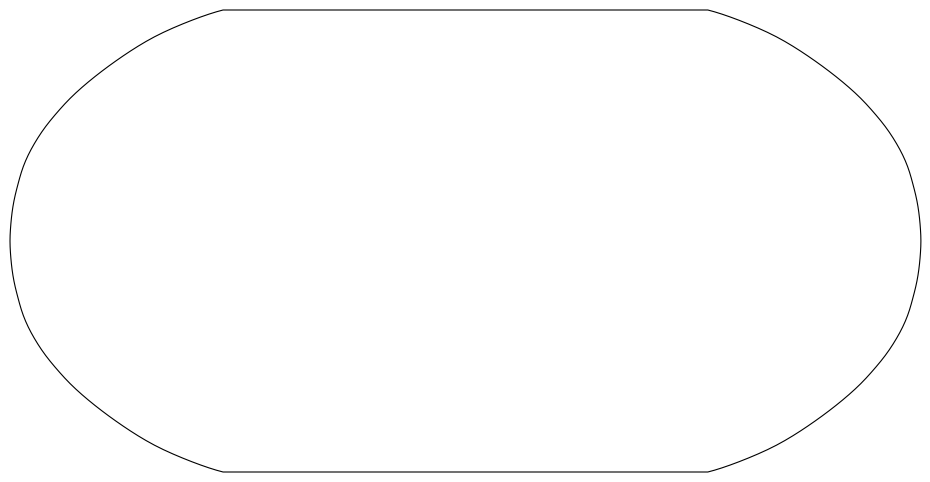

In [37]:
swcf_names = []
for i in range(1,int(180/boxSize)+1):
        for j in range(1,int(360/boxSize)+1):
            swcf_names.append(f"SWCF_{i}_{j}")

import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())

basic_dataset.isel(ens_idx=24,product=0, time=0)[swcf_names].plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    cbar_kwargs={'label': 'SWCF (W/m²)'}
)

ax.coastlines()